# Map Reza

In [1]:
import os
import fitsio
import numpy as np
import healpy as hp
import pandas as pd
import seaborn as sns
from astropy.table import Table
import matplotlib.pyplot as plt
%matplotlib inline

from Simulation.simulMap import *
from Simulation.fitMap import *
from Simulation.utile_fitsFile import *
from Simulation.mappers import Mapper

In [2]:
class DepthMapper(Mapper):
    _mapNameBase = "m5" #base name for all map attributs (ex: self.map, self.mapMasked, self.mapCut...)
    _settingsPlot = Mapper._settingsPlot | {'norm': 'hist', } #default settings to use in self.plot()
    
    def __init__(self, data, nest: bool = True):
        super().__init__(data=data, nest=nest, map=None, dataName="df")
    
    def select_year(self, year : int = 1):
        self.year = year
        idx = self.df['year'] == year
        sel = self.df[idx]
        dfMap = sel.set_index('healpixID')
        IDpix = pd.Index(np.arange(49152))
        self._create_newMap(dfMap.reindex(IDpix), 'year')

    def set_mask(self, band=None, mask=None, badval=-999, **kwargs):
        """Set a mask to self.map and stack it in the attribut self.mapMasked.
        - mask: if given, self.mapMasked.mask = mask. Else, a default mask is set using badval.
        - badval: if mask is not given, value used to define the mask by healpy.ma(self.map, badval=badval).
        - kwargs: if mask is not given, other parametters of healpy.ma() can be given here."""
        if band is None: band = self.band
        map = self._select_useMap(band)
        masked = hp.ma(map, badval=badval, **kwargs)
        if mask is not None: masked.mask = mask
        self._create_newMap(masked, band+'Masked')
        
    def select_band(self, band : str):
        self.band = band
        band_map = self.m5year['m5_'+band].copy()
        band_map.fillna(-999, inplace=True)
        band_map = np.array(band_map)
        self._create_newMap(band_map, band)
    
    def plot(self, band=None, use_map: str = 'Masked', **kwargs):
        if band is None: band = self.band
        band_map = self._select_useMap(band)
        settings = self._settingsPlot | self._instance_settingsPlot | {'unit': f'{self._mapNameBase}_{band}'} | kwargs
        use_map = band + use_map
        super().plot(use_map=use_map, **settings)
    
    def get_m5(self, band=None, **kwargs):
        if band is None: band = self.band
        band_map = self._select_useMap(band)
        if 'healpix_id' in kwargs:
            print("use healpix id to obtain the m5 value on the map")
            healpix_id = kwargs['healpix_id']
        elif 'ra' in kwargs and 'dec' in kwargs:
            print("use ra and dec to find m5 value in the map")
            nside = hp.npix2nside(len(band_map))
            healpix_id = hp.ang2pix(nside, kwargs['ra'], kwargs['dec'], nest=self.nest, lonlat=True)
        return band_map[healpix_id]

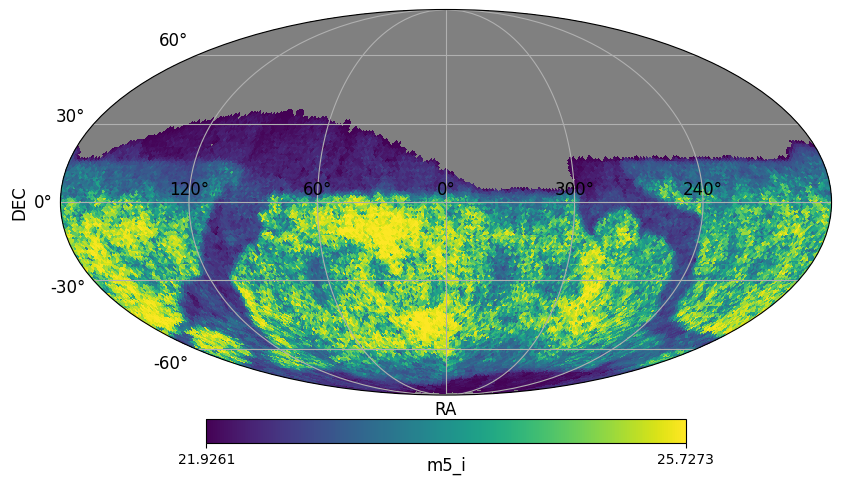

In [3]:
dm = DepthMapper.read_hdf(os.path.join('data','baseline_v5.0.0_10yrs_summary.hdf5'))
dm.select_year(1)
dm.select_band('i')
dm.set_mask()
dm.plot()

In [4]:
dm.get_m5(healpix_id=1)
dm.get_m5(ra=0,dec=0)

use healpix id to obtain the m5 value on the map
use ra and dec to find m5 value in the map


25.352035628207673

In [5]:
dm.df

,healpixID,pixRA,pixDec,nvisits,exposuretime,season_length,cadence,m5_u,nvisits_u,expTime_u,...,m5_z,nvisits_z,expTime_z,cadence_z,m5_y,nvisits_y,expTime_y,cadence_y,year,field
0,41021,228.214286,-79.752828,117,3614.0,3404.069255,83.025462,24.397083,13,494.0,...,23.929728,16,480.0,484.295749,23.174376,15,450.0,484.260905,-1,WFD
1,41021,228.214286,-79.752828,23,722.0,54.121056,9.017992,23.866150,4,152.0,...,23.076346,3,90.0,-1.000000,22.513965,4,120.0,-1.000000,1,WFD
2,41021,228.214286,-79.752828,9,270.0,86.629619,28.870504,-999.000000,0,0.0,...,22.871316,2,60.0,-1.000000,22.443868,4,120.0,-1.000000,2,WFD
3,41021,228.214286,-79.752828,12,360.0,8.147161,-1.000000,-999.000000,0,0.0,...,-999.000000,0,0.0,-1.000000,-999.000000,0,0.0,-1.000000,3,WFD
4,41021,228.214286,-79.752828,1,30.0,0.000000,-1.000000,-999.000000,0,0.0,...,-999.000000,0,0.0,-1.000000,-999.000000,0,0.0,-1.000000,4,WFD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6,17554,18.984375,-10.806923,102,3011.0,355.120954,7.397865,24.336886,7,266.0,...,24.627943,20,600.0,17.825894,23.494756,19,570.0,32.606619,6,WFD
7,17554,18.984375,-10.806923,78,2214.0,363.976530,9.836900,23.689459,3,114.0,...,24.393277,18,450.0,29.669008,23.302566,12,360.0,54.845212,7,WFD
8,17554,18.984375,-10.806923,100,2958.0,354.009648,7.695862,24.369260,6,228.0,...,24.517797,20,510.0,22.785812,23.721321,21,630.0,33.010115,8,WFD
9,17554,18.984375,-10.806923,106,3244.0,358.107411,6.755609,24.452115,8,304.0,...,24.528066,19,570.0,17.547689,23.973277,28,840.0,27.545016,9,WFD


In [6]:
dm.m5year

,pixRA,pixDec,nvisits,exposuretime,season_length,cadence,m5_u,nvisits_u,expTime_u,cadence_u,...,m5_z,nvisits_z,expTime_z,cadence_z,m5_y,nvisits_y,expTime_y,cadence_y,year,field
0,45.000000,0.596842,78.0,2274.0,339.039936,9.971413,23.954747,3.0,114.0,-1.000000,...,24.612723,23.0,600.0,29.636365,23.601241,16.0,480.0,36.774015,1.0,WFD
1,45.703125,1.193748,71.0,2125.0,336.090912,10.841259,24.235524,5.0,190.0,-1.000000,...,24.455579,15.0,405.0,35.894983,23.599425,15.0,450.0,37.150419,1.0,WFD
2,44.296875,1.193748,65.0,1937.0,339.934876,9.711708,24.050415,4.0,152.0,10.918840,...,24.445140,15.0,405.0,27.166632,23.605742,14.0,420.0,33.096571,1.0,WFD
3,45.000000,1.790785,75.0,2229.0,339.036107,10.273461,23.954747,3.0,114.0,-1.000000,...,24.534451,18.0,495.0,29.556391,23.621705,15.0,450.0,29.814150,1.0,WFD
4,46.406250,1.790785,64.0,1839.0,336.095165,10.184278,23.888992,3.0,114.0,-1.000000,...,24.321355,16.0,375.0,35.797191,23.462067,12.0,360.0,33.022595,1.0,WFD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49147,313.593750,-1.790785,76.0,2344.0,179.622328,5.793852,24.307998,8.0,304.0,8.245911,...,24.532141,13.0,390.0,16.239207,23.635018,14.0,420.0,24.943093,1.0,WFD
49148,315.000000,-1.790785,67.0,2050.0,153.687988,4.957125,24.057357,5.0,190.0,8.246297,...,24.542972,13.0,390.0,14.763001,23.461479,12.0,360.0,24.777955,1.0,WFD
49149,315.703125,-1.193748,67.0,2050.0,153.687988,5.298996,24.049222,5.0,190.0,8.246297,...,24.574687,14.0,420.0,16.403287,23.598981,14.0,420.0,24.777955,1.0,WFD
49150,314.296875,-1.193748,76.0,2328.0,153.687988,4.957091,24.238671,6.0,228.0,8.246233,...,24.597256,16.0,480.0,14.763163,23.605622,14.0,420.0,21.238247,1.0,WFD


In [7]:
dm.m5i

array([25.44332135, 25.37015963, 25.36205037, ..., 25.03438478,
       25.14956232, 25.13629296])

In [8]:
dm.m5iMasked

masked_array(data=[25.443321351856355, 25.370159628167585,
                   25.362050369100967, ..., 25.034384777391438,
                   25.149562323320545, 25.13629296383356],
             mask=[False, False, False, ..., False, False, False],
       fill_value=-999.0)

## Reza's data

In [2]:
DIR = 'data/'
FILE = DIR + 'm5i_1y.fits'

data = fitsio.FITS(FILE)
data


  file: data/m5i_1y.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      /home/m5i

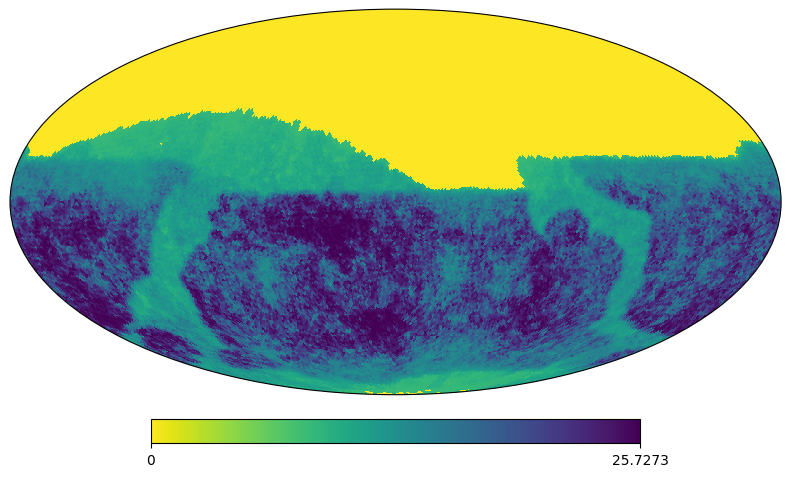

In [47]:
map = Table(data[1].read()).as_array()
map = np.array(map.tolist()).reshape(-1)
hp.projview(map, norm='hist', cmap='viridis_r');

/home/victoria/.local/lib/python3.10/site-packages/iminuit/cost.py:155: RuntimeWarning: divide by zero encountered in divide
  z = (y - ym) / ye


Unable to use minos()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = inf (χ²/ndof = inf)        │              Nfcn = 378              │
│ EDM = nan (Goal: 0.0002)         │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   ABOVE EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │    2e1    │    nan    │            │            │    0    │         │       │
│ 1 │ A    │ 9.5367e-7 │    nan    │            │            │    0    │    1    │       │
│ 2 │ ra   │    2e1    │    nan    │            │            │    0    │   360   │       │
│ 3 │ dec  │    4e1    │    nan    │            │            │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────┐
│     │   M   A  ra dec │
├─────┼─────────────────┤
│   M │ nan nan nan nan │
│   A │ nan nan nan nan │
│  ra │ nan nan nan nan │
│ dec │ nan nan nan nan │
└─────┴─────────────────┘

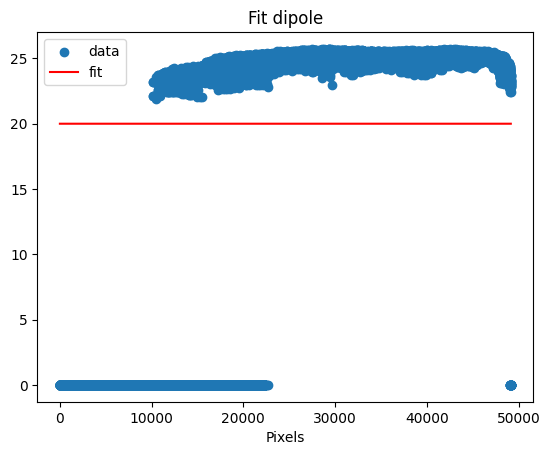

In [49]:
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, frame='icrs', contrast=False)
init =  (20, 0, 20, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))
m

## Phillippe's data

In [4]:
df = pd.read_hdf(DIR + "baseline_v5.0.0_10yrs_summary.hdf5")
df.columns
df.info()
idx = df['year'] == 1
sel = df[idx]
useCol = ['healpixID','pixRA','pixDec','m5_i']
sel[useCol].sort_values('healpixID')

<class 'pandas.core.frame.DataFrame'>
Index: 369327 entries, 0 to 10
Data columns (total 33 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   healpixID      369327 non-null  int64  
 1   pixRA          369327 non-null  float64
 2   pixDec         369327 non-null  float64
 3   nvisits        369327 non-null  int64  
 4   exposuretime   369327 non-null  float64
 5   season_length  369327 non-null  float64
 6   cadence        369327 non-null  float64
 7   m5_u           369327 non-null  float64
 8   nvisits_u      369327 non-null  int64  
 9   expTime_u      369327 non-null  float64
 10  cadence_u      369327 non-null  float64
 11  m5_g           369327 non-null  float64
 12  nvisits_g      369327 non-null  int64  
 13  expTime_g      369327 non-null  float64
 14  cadence_g      369327 non-null  float64
 15  m5_r           369327 non-null  float64
 16  nvisits_r      369327 non-null  int64  
 17  expTime_r      369327 non-null  float6

,healpixID,pixRA,pixDec,m5_i
1,0,45.000000,0.596842,25.443321
1,1,45.703125,1.193748,25.370160
1,2,44.296875,1.193748,25.362050
1,3,45.000000,1.790785,25.478234
1,4,46.406250,1.790785,25.255074
...,...,...,...,...
1,49147,313.593750,-1.790785,25.197838
1,49148,315.000000,-1.790785,25.142484
1,49149,315.703125,-1.193748,25.034385
1,49150,314.296875,-1.193748,25.149562


In [5]:
dfMap = sel.set_index('healpixID')
IDpix = pd.Index(np.arange(49152))
dfMap = dfMap.reindex(IDpix)
dfMap['m5_i'].fillna(-999, inplace=True)
dfMap[useCol[1:]]

/tmp/ipykernel_30429/3755811615.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfMap['m5_i'].fillna(-999, inplace=True)


,pixRA,pixDec,m5_i
0,45.000000,0.596842,25.443321
1,45.703125,1.193748,25.370160
2,44.296875,1.193748,25.362050
3,45.000000,1.790785,25.478234
4,46.406250,1.790785,25.255074
...,...,...,...
49147,313.593750,-1.790785,25.197838
49148,315.000000,-1.790785,25.142484
49149,315.703125,-1.193748,25.034385
49150,314.296875,-1.193748,25.149562


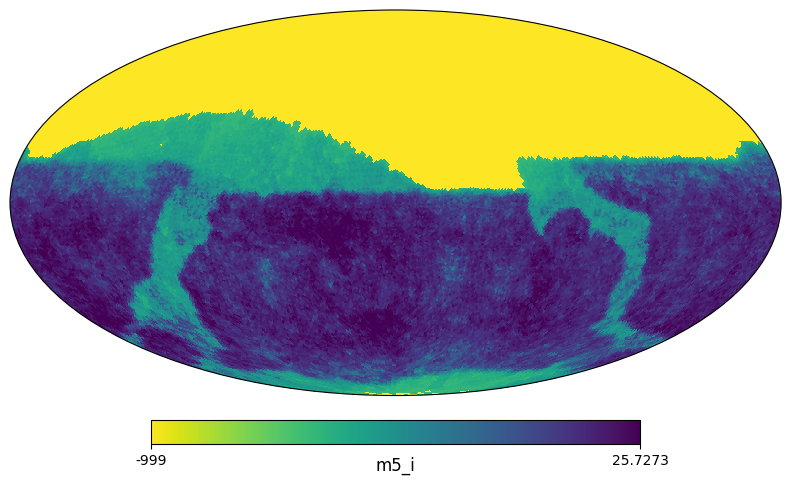

In [6]:
hp.projview(np.array(dfMap['m5_i']), nest=True, norm='hist', unit='m5_i', cmap='viridis_r');

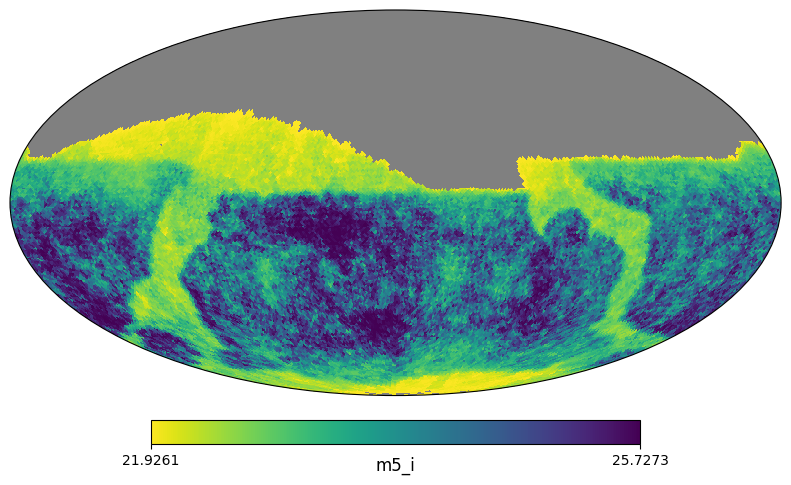

In [55]:
map_masked = hp.ma(dfMap['m5_i'], badval=-999)
hp.projview(map_masked, nest=True, norm='hist', unit='m5_i', cmap='viridis_r');

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.621e+07 (χ²/ndof = 329.9)│              Nfcn = 559              │
│ EDM = 9.99e-05 (Goal: 0.0002)    │            time = 7.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  15.286   │   0.020   │   -0.020   │   0.020    │    0    │         │       │
│ 1 │ A    │ 1.0000000 │ 0.0000034 │ -0.0000034 │ 0.0000034  │    0    │    1    │       │
│ 2 │ ra   │   112.2   │    0.6    │    -0.6    │    0.6     │    0    │   360   │       │
│ 3 │ dec  │  -79.40   │   0.11    │   -0.11    │    0.11    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.02   │   0.02    │  -3.4e-6  │  3.4e-6   │   -0.6    │    0.6    │   -0.11   │   0.11    │
│  Valid   │   True    │   True    │   True    │   False   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────┐
│     │              M              A             ra            dec │
├─────┼─────────────────────────────────────────────────────────────┤
│   M │       0.000397 20.7386115e-21              0             -0 │
│   A │ 20.7386115e-21       3.91e-28  8.0006878e-21  -969.7533e-24 │
│  ra │              0  8.0006878e-21          0.371          0.001 │
│ dec │             -0  -969.7533e-24          0.001         0.0123 │
└─────┴─────────────────────────────────────────────────────────────┘

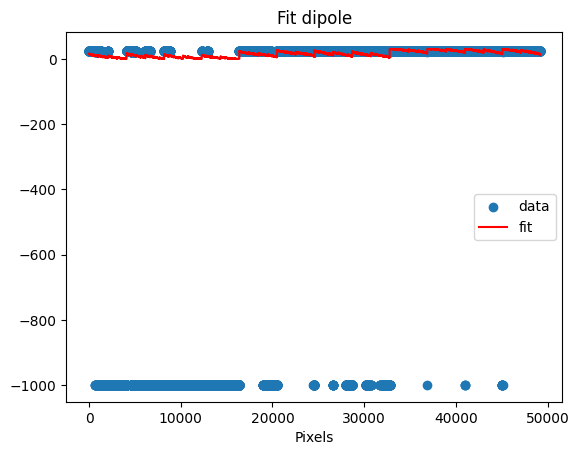

In [56]:
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, frame='icrs', contrast=False)
init =  (20, 0, 20, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map_masked.filled(), init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]))
m

/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/simulMap.py:212: RuntimeWarning: divide by zero encountered in divide
  if weights is not None: y_err = y_err/np.sqrt(weights)


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 322.3 (χ²/ndof = 0.0)      │              Nfcn = 644              │
│ EDM = 6.44e-09 (Goal: 0.0002)    │            time = 8.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │  24.792   │   0.035   │   -0.035   │   0.035    │    0    │   30    │       │
│ 1 │ A    │  0.0227   │  0.0028   │  -0.0027   │   0.0027   │    0    │    1    │       │
│ 2 │ ra   │    80     │    180    │    -80     │    180     │    0    │   360   │       │
│ 3 │ dec  │-89.9999999969│0.9535996361│-0.0000000031│0.9535996361│   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           M           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.035   │   0.035   │  -0.0028  │  0.0027   │    -80    │    180    │  -3.1e-9  │953599636.1e-9│
│  Valid   │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ At Limit │   False   │   False   │   False   │   False   │   True    │   False   │   True    │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   True    │   True    │   False   │   True    │   False   │   True    │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │         M         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│   M │    0.0012    -59e-6    0.0000         0 │
│   A │    -59e-6  7.54e-06     -0e-6        -0 │
│  ra │    0.0000     -0e-6   8.9e+04 49.191e-6 │
│ dec │         0        -0 49.191e-6  1.17e-08 │
└─────┴─────────────────────────────────────────┘

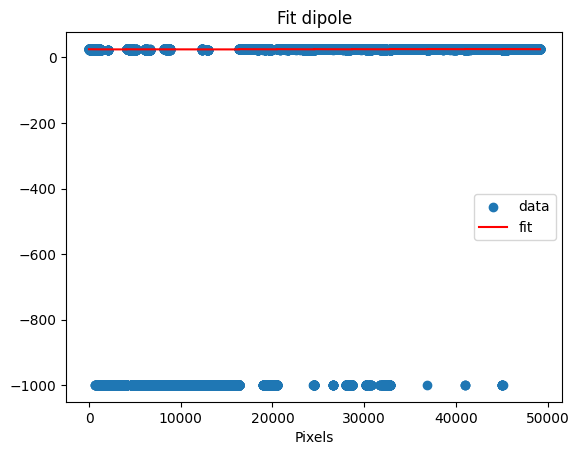

In [57]:
mask = map_masked.mask
mask = ~mask
weights = mask.astype(float)

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=True, frame='icrs', contrast=False)
init =  (20, 0, 20, 40)
names = ("M", "A", "ra", "dec")
m = fit_dipole_err(model, map_masked.filled(), init, names, bounds=([0, 0, 0, -90], [30, 1, 360, 90]), weights=weights)
m

## On simulated map

In [52]:
DIR_fit = "Simulation/Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
FILE_fit = DIR_fit + sufix + '.fits'

data_fit = fitsio.FITS(FILE_fit)
data_fit


  file: Simulation/Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_tests_fit.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS
  2      BINARY_TBL      FIT_NUMPY
  3      BINARY_TBL      FIT_MINUIT

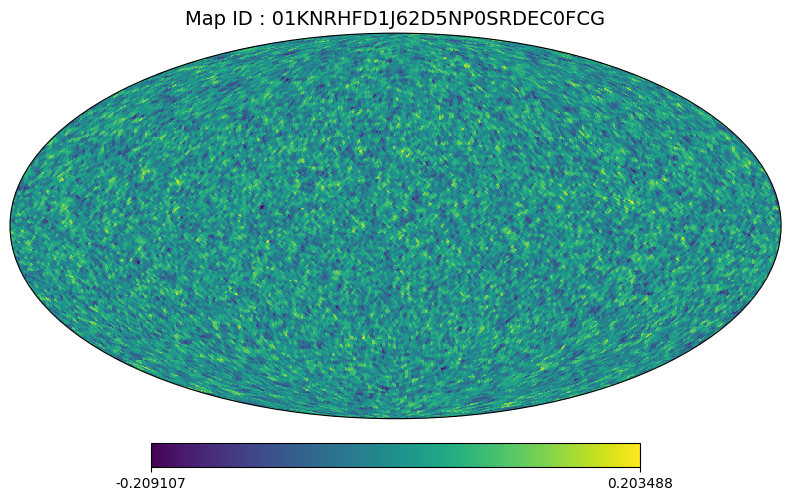

In [59]:
mapID, map_simul = data_fit['MAPS'][0]
hp.projview(map_simul, title=f'Map ID : {mapID}');